In [14]:
import pandas as pd
df = pd.read_csv("mall_customer.csv")
print(df.head())
x = df[["Age", "Annual_Income_k", "Spending_Score"]]

   CustomerID  Age  Annual_Income_k  Spending_Score
0           1   29               17              25
1           2   21               34              56
2           3   25               28              89
3           3   26               34              78
4           4   27               78              56


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
print(X_scaled[:5])

[[-0.82281074 -1.68613693 -1.64422014]
 [-1.74435877 -0.91142537 -0.15550343]
 [-1.28358475 -1.18485298  1.42925951]
 [-1.16839125 -0.91142537  0.90100519]
 [-1.05319775  1.09371044 -0.15550343]]


C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


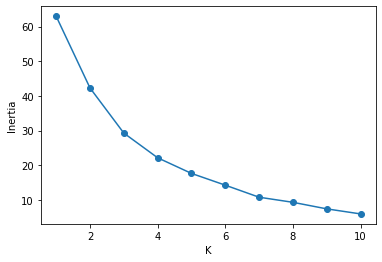

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df["Cluster"] = kmeans.labels_
print(df["Cluster"].value_counts())

2    7
4    5
1    5
0    3
3    1
Name: Cluster, dtype: int64


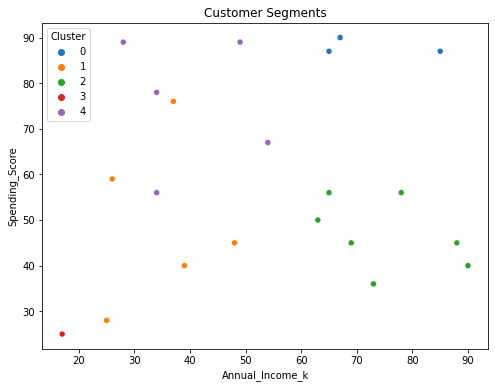

In [27]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data = df, x = "Annual_Income_k", y = "Spending_Score", hue ="Cluster", palette="tab10")
plt.title("Customer Segments")
plt.show()